# Extension - Hierarchical Bayesian Cue Integration Model

This notebook contains the extended model comparison and fits for *Rouault et al. (2019)*, proposing 3 candidate models:
1. A Bayesian learning model with uncertainty-aversion (lambda model, Gaussian with risk-sensitive penalty)
2. A Bayesian cue integration model (eta model, with graded weights accorded to different evidence types : confidence, versus feedback)
3. A combined model, incorporating changes to the perceptual module (cue integration), and decision rules on task choices (uncertainty-aversion)

All models and the motivation for their proposal are specified in detail in the full write-up (refer to `README.md`).

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import itertools
import time
from pathlib import Path
from scipy.special import expit
from scipy.optimize import minimize
from scipy.stats import norm
import os
from scipy.special import softmax

os.makedirs('../docs/figures', exist_ok=True)

In [96]:
# Reconstruction of trial-level data and choices per subject, to fit the model (Exp3.mat and Exp2.mat only have analyses and aggregate-level data)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
Exp2 = sio.loadmat(
    project_root / "data" / "Exp2.mat",
    squeeze_me=True, struct_as_record=False
)["Exp2"]

task1val_exp2 = np.array(Exp2.task1val) # (6, 5, 29) with binary values (1=choose T1)
acct1perser = np.array(Exp2.acct1perser) # (29, 6)
acct2perser = np.array(Exp2.acct2perser) # (29, 6)
n_subjects = task1val_exp2.shape[2] # 29

# kch per subject
avg_acc = np.mean(np.hstack([acct1perser, acct2perser]), axis=1)
avg_acc = np.clip(avg_acc, 0.51, 0.99)
d_prime = norm.ppf(avg_acc) - norm.ppf(1 - avg_acc)
delta_avg = (60 + 24) / 2
kch_all = d_prime / (2 * delta_avg)
print(f"kch range: {kch_all.min():.4f} – {kch_all.max():.4f}, with mean: {kch_all.mean():.4f}")

# Methods section - experimental design setup
# Cols = T1_accuracy, T1_fbtype, T2_accuracy, T2_fbtype
series_design = [
    (70, 1, 85, 1), # DF vs EF
    (70, 1, 70, 0), # DF vs DNF
    (85, 0, 70, 1), # ENF vs DF
    (85, 1, 70, 0), # EF vs DNF
    (85, 0, 85, 1), # ENF vs EF
    (70, 0, 85, 0), # DNF vs ENF
]

trial_counts_per_task = [4, 8, 12, 16, 20] 


def build_subject_data(subj_idx, rng=None):
    if rng is None:
        rng = np.random.default_rng(subj_idx)

    LBduration = np.array([2 * d for _ in series_design
                                 for d in trial_counts_per_task], dtype=int)
    n_series = len(LBduration) 
    n_trials = int(LBduration.sum())

    accuracylevel = np.zeros(n_trials, dtype=int)
    fbtype = np.zeros(n_trials, dtype=int)
    currenttask = np.zeros(n_trials, dtype=int)
    target_left = rng.integers(0, 2, size=n_trials)

    idx = 0
    for pairing_i, (t1_acc, t1_fb, t2_acc, t2_fb) in enumerate(series_design):
        for dur in trial_counts_per_task:
            for t in range(2 * dur):
                task = 1 if t % 2 == 0 else 2
                currenttask[idx] = task
                accuracylevel[idx] = t1_acc if task == 1 else t2_acc
                fbtype[idx] = t1_fb if task == 1 else t2_fb
                idx += 1

    # Choices come from task1val[pairing, duration, subject]
    choices_raw   = task1val_exp2[:, :, subj_idx].flatten().astype(int)
    choices_model = np.where(choices_raw == 1, 1, 2)

    return {
        'accuracylevel': accuracylevel,
        'fbtype': fbtype,
        'currenttask': currenttask,
        'target_left': target_left,
        'seriestype': np.arange(1, n_series + 1),
        'LBduration': LBduration,
        'kch': kch_all[subj_idx],
        'choices': choices_model,
    }

all_subjects = {s: build_subject_data(s) for s in range(n_subjects)}
print(f"{n_subjects} subjects confirmed, {len(all_subjects[0]['choices'])} choices each.")

s0 = all_subjects[0]
print(f"\nSubject 0 Test :")
print(f"Kch = {s0['kch']:.4f}")
print(f"Choices = {s0['choices']}")
print(f"LBduration = {s0['LBduration']}")
print(f"Total trials = {s0['LBduration'].sum()}")
print(f"Accuracylevel = {s0['accuracylevel'][:8]}")
print(f"Fbtype = {s0['fbtype'][:8]}")

kch range: 0.0099 – 0.0280, with mean: 0.0187
29 subjects confirmed, 30 choices each.

Subject 0 Test :
Kch = 0.0144
Choices = [1 2 1 2 2 1 1 1 1 1 2 2 2 2 2 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]
LBduration = [ 8 16 24 32 40  8 16 24 32 40  8 16 24 32 40  8 16 24 32 40  8 16 24 32
 40  8 16 24 32 40]
Total trials = 720
Accuracylevel = [70 85 70 85 70 85 70 85]
Fbtype = [1 1 1 1 1 1 1 1]


In [97]:
# Python translation of the original MATLAB BAY_learning model [under `SCRIPTS` in original repo]

def bay_learning_model(
    accuracylevel, fbtype, currenttask, target_left,
    seriestype, LBduration, kch, kconf,
    nb_iter=1000, nb_beta_samples=100_000,
    easy=60, hard=24, alpha0=6, beta0=3,
    random_state=None,
):
    rng = np.random.default_rng(random_state)
    accuracylevel = np.asarray(accuracylevel)
    fbtype = np.asarray(fbtype)
    currenttask = np.asarray(currenttask)
    target_left = np.asarray(target_left)
    seriestype = np.asarray(seriestype)
    LBduration = np.asarray(LBduration, dtype=int)
    n_trials = int(LBduration.sum())
    n_series = len(seriestype)

    d = target_left.astype(float).copy()
    d[target_left == 1] = -1
    d[target_left == 0] = 1

    a = np.zeros(n_trials, dtype=int)
    correct = np.zeros(n_trials, dtype=int)
    chosen_task = np.zeros(n_series, dtype=int)
    pWh = np.zeros((n_series, 2), dtype=float)
    esperance_T1 = np.zeros((nb_iter, n_trials), dtype=float)
    esperance_T2 = np.zeros((nb_iter, n_trials), dtype=float)

    block_starts = np.r_[0, np.cumsum(LBduration[:-1])]
    alphaT1, betaT1 = alpha0, beta0
    alphaT2, betaT2 = alpha0, beta0

    for ser in range(n_series):
        start = block_starts[ser]
        duration = LBduration[ser]
        Q_iterred = np.zeros((nb_iter, 4), dtype=float)

        for iteration in range(nb_iter):
            X = np.zeros(duration, dtype=float)
            p_success = np.zeros(duration, dtype=float)

            for t in range(duration):
                idx = start + t
                dot_difference = hard if accuracylevel[idx] == 70 else easy

                dhat_left = -kconf * dot_difference
                dhat_right =  kconf * dot_difference

                X[t] = rng.normal(loc=d[idx] * kch * dot_difference, scale=1)
                a[idx] = 1 if X[t] < 0 else 0
                correct[idx] = int(a[idx] == target_left[idx])

                p_right = expit((dhat_right - dhat_left) * X[t])
                p_success[t] = p_right if X[t] > 0 else 1 - p_right

                if t == 0:
                    alphaT1, betaT1 = alpha0, beta0
                    alphaT2, betaT2 = alpha0, beta0
                elif fbtype[idx] == 1:
                    if currenttask[idx] == 1:
                        alphaT1 += 1 if correct[idx] == 1 else 0
                        betaT1 += 0 if correct[idx] == 1 else 1
                    elif currenttask[idx] == 2:
                        alphaT2 += 1 if correct[idx] == 1 else 0
                        betaT2 += 0 if correct[idx] == 1 else 1
                elif fbtype[idx] == 0:
                    if currenttask[idx] == 1:
                        alphaT1 += p_success[t]
                        betaT1 += 1 - p_success[t]
                    elif currenttask[idx] == 2:
                        alphaT2 += p_success[t]
                        betaT2 += 1 - p_success[t]

                esperance_T1[iteration, idx] = alphaT1 / (alphaT1 + betaT1)
                esperance_T2[iteration, idx] = alphaT2 / (alphaT2 + betaT2)

            Q_iterred[iteration, :] = [alphaT1, betaT1, alphaT2, betaT2]

        alphaT1, betaT1, alphaT2, betaT2 = Q_iterred.mean(axis=0)

        # Original Monte Carlo comparison (paper's specification)
        beliefT1 = rng.beta(alphaT1, betaT1, size=nb_beta_samples)
        beliefT2 = rng.beta(alphaT2, betaT2, size=nb_beta_samples)
        delta_belief = beliefT1 - beliefT2
        proba_T1 = np.mean(delta_belief > 0)
        proba_T2 = np.mean(delta_belief < 0)

        pWh[ser, :] = [proba_T1, proba_T2]
        pWh[ser, :] /= pWh[ser, :].sum()
        chosen_task[ser] = 1 if rng.random() < pWh[ser, 0] else 2

    return {
        "chosen_task": chosen_task, "pWh": pWh,
        "a": a, "correct": correct,
        "esperance_T1": esperance_T1, "esperance_T2": esperance_T2,
    }

In [98]:
# Bayesian extended model with uncertainty-aversion (lambda model)

def bay_learning_model_extended(
    accuracylevel, fbtype, currenttask, target_left,
    seriestype, LBduration, kch, kconf,
    lambda_risk=0.0,
    nb_iter=50, nb_beta_samples=100_000,
    easy=60, hard=24, alpha0=6, beta0=3,
    random_state=None,
):
    rng = np.random.default_rng(random_state)
    accuracylevel = np.asarray(accuracylevel)
    fbtype        = np.asarray(fbtype)
    currenttask   = np.asarray(currenttask)
    target_left   = np.asarray(target_left)
    seriestype    = np.asarray(seriestype)
    LBduration    = np.asarray(LBduration, dtype=int)
    n_trials      = int(LBduration.sum())
    n_series      = len(seriestype)

    d = target_left.astype(float).copy()
    d[target_left == 1] = -1
    d[target_left == 0] = 1

    a = np.zeros(n_trials, dtype=int)
    correct = np.zeros(n_trials, dtype=int)
    chosen_task = np.zeros(n_series, dtype=int)
    pWh = np.zeros((n_series, 2), dtype=float)
    esperance_T1 = np.zeros((nb_iter, n_trials), dtype=float)
    esperance_T2 = np.zeros((nb_iter, n_trials), dtype=float)

    block_starts = np.r_[0, np.cumsum(LBduration[:-1])]
    alphaT1, betaT1 = alpha0, beta0
    alphaT2, betaT2 = alpha0, beta0

    for ser in range(n_series):
        start = block_starts[ser]
        duration = LBduration[ser]
        Q_iterred = np.zeros((nb_iter, 4), dtype=float)

        for iteration in range(nb_iter):
            X = np.zeros(duration, dtype=float)
            p_success = np.zeros(duration, dtype=float)

            for t in range(duration):
                idx = start + t
                dot_difference = hard if accuracylevel[idx] == 70 else easy

                dhat_left = -kconf * dot_difference
                dhat_right = kconf * dot_difference

                X[t] = rng.normal(loc=d[idx] * kch * dot_difference, scale=1)
                a[idx] = 1 if X[t] < 0 else 0
                correct[idx] = int(a[idx] == target_left[idx])

                p_right = expit((dhat_right - dhat_left) * X[t])
                p_success[t] = p_right if X[t] > 0 else 1 - p_right

                # Learning module (identical to original model)
                if t == 0:
                    alphaT1, betaT1 = alpha0, beta0
                    alphaT2, betaT2 = alpha0, beta0
                elif fbtype[idx] == 1:
                    if currenttask[idx] == 1:
                        alphaT1 += 1 if correct[idx] == 1 else 0
                        betaT1 += 0 if correct[idx] == 1 else 1
                    elif currenttask[idx] == 2:
                        alphaT2 += 1 if correct[idx] == 1 else 0
                        betaT2 += 0 if correct[idx] == 1 else 1
                elif fbtype[idx] == 0:
                    if currenttask[idx] == 1:
                        alphaT1 += p_success[t]
                        betaT1 += 1 - p_success[t]
                    elif currenttask[idx] == 2:
                        alphaT2 += p_success[t]
                        betaT2 += 1 - p_success[t]

                esperance_T1[iteration, idx] = alphaT1 / (alphaT1 + betaT1)
                esperance_T2[iteration, idx] = alphaT2 / (alphaT2 + betaT2)

            Q_iterred[iteration, :] = [alphaT1, betaT1, alphaT2, betaT2]

        alphaT1, betaT1, alphaT2, betaT2 = Q_iterred.mean(axis=0)

        # Extended comparison, uses a Gaussian w. risk-sensitive variance penalty
        mu1 = alphaT1 / (alphaT1 + betaT1)
        mu2 = alphaT2 / (alphaT2 + betaT2)
        var1 = mu1 * (1 - mu1) / (alphaT1 + betaT1 + 1)
        var2 = mu2 * (1 - mu2) / (alphaT2 + betaT2 + 1)

        U1 = mu1 - lambda_risk * np.sqrt(var1)
        U2 = mu2 - lambda_risk * np.sqrt(var2)

        se_diff  = np.sqrt(var1 + var2)
        z = (U2 - U1) / se_diff if se_diff > 1e-10 else 0.0
        proba_T2 = float(norm.cdf(z))
        proba_T1 = 1.0 - proba_T2

        pWh[ser, :] = [proba_T1, proba_T2]
        pWh[ser, :] /= pWh[ser, :].sum()
        chosen_task[ser] = 1 if rng.random() < pWh[ser, 0] else 2

    return {
        "chosen_task": chosen_task, "pWh": pWh,
        "a": a, "correct": correct,
        "esperance_T1": esperance_T1, "esperance_T2": esperance_T2,
    }

In [99]:
# Bayesian extended cue integration model (eta model)

def bay_learning_model_eta(
    accuracylevel, fbtype, currenttask, target_left,
    seriestype, LBduration, kch, kconf,
    eta=1.0,
    nb_iter=50, nb_beta_samples=100_000,
    easy=60, hard=24, alpha0=6, beta0=3,
    random_state=None,
):
    rng = np.random.default_rng(random_state)
    accuracylevel = np.asarray(accuracylevel)
    fbtype = np.asarray(fbtype)
    currenttask = np.asarray(currenttask)
    target_left = np.asarray(target_left)
    seriestype = np.asarray(seriestype)
    LBduration = np.asarray(LBduration, dtype=int)
    n_trials = int(LBduration.sum())
    n_series = len(seriestype)
 
    d = target_left.astype(float).copy()
    d[target_left == 1] = -1
    d[target_left == 0] = 1
 
    a = np.zeros(n_trials, dtype=int)
    correct = np.zeros(n_trials, dtype=int)
    chosen_task = np.zeros(n_series, dtype=int)
    pWh = np.zeros((n_series, 2), dtype=float)
    esperance_T1 = np.zeros((nb_iter, n_trials), dtype=float)
    esperance_T2 = np.zeros((nb_iter, n_trials), dtype=float)
 
    block_starts = np.r_[0, np.cumsum(LBduration[:-1])]
    alphaT1, betaT1 = alpha0, beta0
    alphaT2, betaT2 = alpha0, beta0
 
    for ser in range(n_series):
        start = block_starts[ser]
        duration = LBduration[ser]
        Q_iterred = np.zeros((nb_iter, 4), dtype=float)
 
        for iteration in range(nb_iter):
            X = np.zeros(duration, dtype=float)
            p_success = np.zeros(duration, dtype=float)
 
            for t in range(duration):
                idx = start + t
                dot_difference = hard if accuracylevel[idx] == 70 else easy
 
                dhat_left  = -kconf * dot_difference
                dhat_right =  kconf * dot_difference
 
                X[t] = rng.normal(loc=d[idx] * kch * dot_difference, scale=1)
                a[idx] = 1 if X[t] < 0 else 0
                correct[idx] = int(a[idx] == target_left[idx])
 
                p_right = expit((dhat_right - dhat_left) * X[t])
                p_success[t] = p_right if X[t] > 0 else 1 - p_right
 
                # Learning module is the one that changes : eta defines weights accorded to feedback vs. confidence on feedback trials
                if t == 0:
                    alphaT1, betaT1 = alpha0, beta0
                    alphaT2, betaT2 = alpha0, beta0
                elif fbtype[idx] == 1:
                    fb_correct = float(correct[idx])
                    update_alpha = eta * fb_correct   + (1 - eta) * p_success[t]
                    update_beta  = eta * (1 - fb_correct) + (1 - eta) * (1 - p_success[t])
                    if currenttask[idx] == 1:
                        alphaT1 += update_alpha
                        betaT1  += update_beta
                    elif currenttask[idx] == 2:
                        alphaT2 += update_alpha
                        betaT2  += update_beta
                elif fbtype[idx] == 0:
                    if currenttask[idx] == 1:
                        alphaT1 += p_success[t]
                        betaT1  += 1 - p_success[t]
                    elif currenttask[idx] == 2:
                        alphaT2 += p_success[t]
                        betaT2  += 1 - p_success[t]
 
                esperance_T1[iteration, idx] = alphaT1 / (alphaT1 + betaT1)
                esperance_T2[iteration, idx] = alphaT2 / (alphaT2 + betaT2)
 
            Q_iterred[iteration, :] = [alphaT1, betaT1, alphaT2, betaT2]
 
        alphaT1, betaT1, alphaT2, betaT2 = Q_iterred.mean(axis=0)
 
        # Decision module stays with original MC comparison
        beliefT1 = rng.beta(alphaT1, betaT1, size=nb_beta_samples)
        beliefT2 = rng.beta(alphaT2, betaT2, size=nb_beta_samples)
        delta_belief = beliefT1 - beliefT2
        proba_T1 = np.mean(delta_belief > 0)
        proba_T2 = np.mean(delta_belief < 0)
 
        pWh[ser, :] = [proba_T1, proba_T2]
        pWh[ser, :] /= pWh[ser, :].sum()
        chosen_task[ser] = 1 if rng.random() < pWh[ser, 0] else 2
 
    return {
        "chosen_task": chosen_task, "pWh": pWh,
        "a": a, "correct": correct,
        "esperance_T1": esperance_T1, "esperance_T2": esperance_T2,
    }

In [100]:
# Bayesian extended combined model (eta + lambda)

def bay_learning_model_combined(
    accuracylevel, fbtype, currenttask, target_left,
    seriestype, LBduration, kch, kconf,
    eta=1.0, lambda_risk=0.0,
    nb_iter=50, nb_beta_samples=100_000,
    easy=60, hard=24, alpha0=6, beta0=3,
    random_state=None,
):
    rng = np.random.default_rng(random_state)
    accuracylevel = np.asarray(accuracylevel)
    fbtype = np.asarray(fbtype)
    currenttask = np.asarray(currenttask)
    target_left = np.asarray(target_left)
    seriestype = np.asarray(seriestype)
    LBduration = np.asarray(LBduration, dtype=int)
    n_trials = int(LBduration.sum())
    n_series = len(seriestype)
 
    d = target_left.astype(float).copy()
    d[target_left == 1] = -1
    d[target_left == 0] = 1
 
    a = np.zeros(n_trials, dtype=int)
    correct = np.zeros(n_trials, dtype=int)
    chosen_task = np.zeros(n_series, dtype=int)
    pWh = np.zeros((n_series, 2), dtype=float)
    esperance_T1 = np.zeros((nb_iter, n_trials), dtype=float)
    esperance_T2 = np.zeros((nb_iter, n_trials), dtype=float)
 
    block_starts = np.r_[0, np.cumsum(LBduration[:-1])]
    alphaT1, betaT1 = alpha0, beta0
    alphaT2, betaT2 = alpha0, beta0
 
    for ser in range(n_series):
        start = block_starts[ser]
        duration = LBduration[ser]
        Q_iterred = np.zeros((nb_iter, 4), dtype=float)
 
        for iteration in range(nb_iter):
            X = np.zeros(duration, dtype=float)
            p_success = np.zeros(duration, dtype=float)
 
            for t in range(duration):
                idx = start + t
                dot_difference = hard if accuracylevel[idx] == 70 else easy
 
                dhat_left = -kconf * dot_difference
                dhat_right =  kconf * dot_difference
 
                X[t] = rng.normal(loc=d[idx] * kch * dot_difference, scale=1)
                a[idx] = 1 if X[t] < 0 else 0
                correct[idx] = int(a[idx] == target_left[idx])
 
                p_right = expit((dhat_right - dhat_left) * X[t])
                p_success[t] = p_right if X[t] > 0 else 1 - p_right
 
                if t == 0:
                    alphaT1, betaT1 = alpha0, beta0
                    alphaT2, betaT2 = alpha0, beta0
                elif fbtype[idx] == 1:
                    fb_correct = float(correct[idx])
                    update_alpha = eta * fb_correct   + (1 - eta) * p_success[t]
                    update_beta  = eta * (1 - fb_correct) + (1 - eta) * (1 - p_success[t])
                    if currenttask[idx] == 1:
                        alphaT1 += update_alpha
                        betaT1  += update_beta
                    elif currenttask[idx] == 2:
                        alphaT2 += update_alpha
                        betaT2  += update_beta
                elif fbtype[idx] == 0:
                    if currenttask[idx] == 1:
                        alphaT1 += p_success[t]
                        betaT1  += 1 - p_success[t]
                    elif currenttask[idx] == 2:
                        alphaT2 += p_success[t]
                        betaT2  += 1 - p_success[t]
 
                esperance_T1[iteration, idx] = alphaT1 / (alphaT1 + betaT1)
                esperance_T2[iteration, idx] = alphaT2 / (alphaT2 + betaT2)
 
            Q_iterred[iteration, :] = [alphaT1, betaT1, alphaT2, betaT2]
 
        alphaT1, betaT1, alphaT2, betaT2 = Q_iterred.mean(axis=0)
 
        # Decision module changes: mean-variance utility with lambda
        mu1  = alphaT1 / (alphaT1 + betaT1)
        mu2  = alphaT2 / (alphaT2 + betaT2)
        var1 = mu1 * (1 - mu1) / (alphaT1 + betaT1 + 1)
        var2 = mu2 * (1 - mu2) / (alphaT2 + betaT2 + 1)
 
        U1 = mu1 - lambda_risk * np.sqrt(var1)
        U2 = mu2 - lambda_risk * np.sqrt(var2)
 
        se_diff  = np.sqrt(var1 + var2)
        z = (U2 - U1) / se_diff if se_diff > 1e-10 else 0.0
        proba_T2 = float(norm.cdf(z))
        proba_T1 = 1.0 - proba_T2
 
        pWh[ser, :] = [proba_T1, proba_T2]
        pWh[ser, :] /= pWh[ser, :].sum()
        chosen_task[ser] = 1 if rng.random() < pWh[ser, 0] else 2
 
    return {
        "chosen_task": chosen_task, "pWh": pWh,
        "a": a, "correct": correct,
        "esperance_T1": esperance_T1, "esperance_T2": esperance_T2,
    }

In [101]:
# Negative log-likelihod across models

# NLL for original model
def neg_log_likelihood_orig(params, subject_data, kch):
    kconf = params[0]
    if kconf <= 0:
        return 1e10

    result = bay_learning_model(
        accuracylevel=subject_data['accuracylevel'],
        fbtype=subject_data['fbtype'],
        currenttask=subject_data['currenttask'],
        target_left=subject_data['target_left'],
        seriestype=subject_data['seriestype'],
        LBduration=subject_data['LBduration'],
        kch=kch,
        kconf=kconf,
        nb_iter=50,
        random_state=42,
    )
    pWh = result['pWh']
    choices = subject_data['choices']
    ll = 0.0
    for ser, choice in enumerate(choices):
        p = np.clip(pWh[ser, choice - 1], 1e-10, 1 - 1e-10)
        ll += np.log(p)
    return -ll


# NLL for lambda model
def neg_log_likelihood_lam(params, subject_data, kch):
    kconf, lambda_risk = params
    if lambda_risk < 0 or kconf <= 0:
        return 1e10
 
    result = bay_learning_model_extended(
        accuracylevel=subject_data['accuracylevel'],
        fbtype=subject_data['fbtype'],
        currenttask=subject_data['currenttask'],
        target_left=subject_data['target_left'],
        seriestype=subject_data['seriestype'],
        LBduration=subject_data['LBduration'],
        kch=kch, kconf=kconf, lambda_risk=lambda_risk,
        nb_iter=50, random_state=42,
    )
    pWh = result['pWh']
    choices = subject_data['choices']
    ll = 0.0
    for ser, choice in enumerate(choices):
        p = np.clip(pWh[ser, choice - 1], 1e-10, 1 - 1e-10)
        ll += np.log(p)
    return -ll
 

# NLL for eta model
def neg_log_likelihood_eta(params, subject_data, kch):
    kconf, eta = params
    if kconf <= 0 or eta < 0 or eta > 1:
        return 1e10
 
    result = bay_learning_model_eta(
        accuracylevel=subject_data['accuracylevel'],
        fbtype=subject_data['fbtype'],
        currenttask=subject_data['currenttask'],
        target_left=subject_data['target_left'],
        seriestype=subject_data['seriestype'],
        LBduration=subject_data['LBduration'],
        kch=kch, kconf=kconf, eta=eta,
        nb_iter=50, random_state=42,
    )
    pWh = result['pWh']
    choices = subject_data['choices']
    ll = 0.0
    for ser, choice in enumerate(choices):
        p = np.clip(pWh[ser, choice - 1], 1e-10, 1 - 1e-10)
        ll += np.log(p)
    return -ll
 

# NLL for combined model
def neg_log_likelihood_combined(params, subject_data, kch):
    kconf, eta, lambda_risk = params
    if kconf <= 0 or eta < 0 or eta > 1 or lambda_risk < 0:
        return 1e10
 
    result = bay_learning_model_combined(
        accuracylevel=subject_data['accuracylevel'],
        fbtype=subject_data['fbtype'],
        currenttask=subject_data['currenttask'],
        target_left=subject_data['target_left'],
        seriestype=subject_data['seriestype'],
        LBduration=subject_data['LBduration'],
        kch=kch, kconf=kconf, eta=eta, lambda_risk=lambda_risk,
        nb_iter=50, random_state=42,
    )
    pWh = result['pWh']
    choices = subject_data['choices']
    ll = 0.0
    for ser, choice in enumerate(choices):
        p = np.clip(pWh[ser, choice - 1], 1e-10, 1 - 1e-10)
        ll += np.log(p)
    return -ll
 

In [102]:
# Grid initialisation (coarse grid searhc -> L-BFGS-B refinement)

kconf_grid = np.logspace(-2, 0, 8)
eta_grid = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
lambda_grid = np.array([0.0, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0])
 
print("kconf grid:", np.round(kconf_grid, 4))
print("eta grid:", eta_grid)
print("lambda grid:", lambda_grid)
 
fitted_all = {}
 
for subj_id, subject_data in all_subjects.items():
    kch_subj = subject_data['kch']
    t0 = time.time()
 
    # Original model (1 parameter = kconf)
    best_nll, best_kc = np.inf, 0.02
    for kc in kconf_grid:
        nll = neg_log_likelihood_orig([kc], subject_data, kch_subj)
        if nll < best_nll:
            best_nll, best_kc = nll, kc
    res_orig = minimize(
        neg_log_likelihood_orig, x0=[best_kc],
        args=(subject_data, kch_subj),
        method='L-BFGS-B', bounds=[(0.001, 1.0)],
        options={'ftol': 1e-4, 'maxiter': 300},
    )
 
    # Lambda model (2 parameters = kconf, lambda)
    best_nll, best_p = np.inf, (0.02, 5.0)
    for kc, lam in itertools.product(kconf_grid, lambda_grid):
        nll = neg_log_likelihood_lam([kc, lam], subject_data, kch_subj)
        if nll < best_nll:
            best_nll, best_p = nll, (kc, lam)
    res_lam = minimize(
        neg_log_likelihood_lam, x0=list(best_p),
        args=(subject_data, kch_subj),
        method='L-BFGS-B', bounds=[(0.001, 1.0), (0.0, 200.0)],
        options={'ftol': 1e-4, 'maxiter': 300},
    )
 
    # Eta model (2 parameters = kconf, eta)
    best_nll, best_p = np.inf, (0.02, 1.0)
    for kc, et in itertools.product(kconf_grid, eta_grid):
        nll = neg_log_likelihood_eta([kc, et], subject_data, kch_subj)
        if nll < best_nll:
            best_nll, best_p = nll, (kc, et)
    res_eta = minimize(
        neg_log_likelihood_eta, x0=list(best_p),
        args=(subject_data, kch_subj),
        method='L-BFGS-B', bounds=[(0.001, 1.0), (0.0, 1.0)],
        options={'ftol': 1e-4, 'maxiter': 300},
    )
 
    # Eta+Lambda combined model (3 parameters = kconf, eta, lambda)
    best_nll, best_p = np.inf, (0.02, 1.0, 5.0)
    for kc, et, lam in itertools.product(kconf_grid, eta_grid, lambda_grid):
        nll = neg_log_likelihood_combined([kc, et, lam], subject_data, kch_subj)
        if nll < best_nll:
            best_nll, best_p = nll, (kc, et, lam)
    res_comb = minimize(
        neg_log_likelihood_combined, x0=list(best_p),
        args=(subject_data, kch_subj),
        method='L-BFGS-B', bounds=[(0.001, 1.0), (0.0, 1.0), (0.0, 200.0)],
        options={'ftol': 1e-4, 'maxiter': 300},
    )
 
    elapsed = time.time() - t0
    fitted_all[subj_id] = {
        'kconf_orig': res_orig.x[0], 'nll_orig': res_orig.fun,
        'kconf_lam': res_lam.x[0], 'lambda': res_lam.x[1], 'nll_lam': res_lam.fun,
        'kconf_eta': res_eta.x[0], 'eta': res_eta.x[1], 'nll_eta': res_eta.fun,
        'kconf_comb': res_comb.x[0], 'eta_comb': res_comb.x[1],
        'lambda_comb': res_comb.x[2], 'nll_comb': res_comb.fun,
    }
 
    print(
        f"S{subj_id:02d} ({elapsed:.1f}s): "
        f"orig={res_orig.fun:.2f} | "
        f"λ={res_lam.x[1]:.1f} NLL={res_lam.fun:.2f} | "
        f"η={res_eta.x[1]:.2f} NLL={res_eta.fun:.2f} | "
        f"η={res_comb.x[1]:.2f},λ={res_comb.x[2]:.1f} NLL={res_comb.fun:.2f}"
    )

kconf grid: [0.01   0.0193 0.0373 0.072  0.1389 0.2683 0.5179 1.    ]
eta grid: [0.  0.2 0.4 0.6 0.8 1. ]
lambda grid: [ 0.  1.  2.  5. 10. 20. 50.]
S00 (47.5s): orig=17.62 | λ=8.3 NLL=11.63 | η=1.00 NLL=17.62 | η=1.00,λ=8.3 NLL=11.63
S01 (44.5s): orig=17.37 | λ=2.0 NLL=17.14 | η=0.80 NLL=18.16 | η=1.00,λ=2.0 NLL=17.14
S02 (45.2s): orig=18.67 | λ=0.0 NLL=17.14 | η=1.00 NLL=18.67 | η=1.00,λ=0.0 NLL=17.14
S03 (43.3s): orig=18.50 | λ=0.0 NLL=18.56 | η=0.40 NLL=18.31 | η=0.60,λ=0.0 NLL=18.51
S04 (54.7s): orig=12.34 | λ=20.0 NLL=8.83 | η=1.00 NLL=12.34 | η=0.00,λ=20.0 NLL=8.80
S05 (49.8s): orig=16.51 | λ=0.0 NLL=16.44 | η=0.80 NLL=16.30 | η=1.00,λ=0.0 NLL=16.44
S06 (42.3s): orig=21.94 | λ=0.0 NLL=22.38 | η=0.00 NLL=20.25 | η=0.00,λ=2.0 NLL=20.59
S07 (43.9s): orig=19.84 | λ=1.2 NLL=17.94 | η=0.00 NLL=19.80 | η=0.00,λ=10.0 NLL=18.67
S08 (43.5s): orig=19.41 | λ=0.0 NLL=17.88 | η=0.60 NLL=19.18 | η=1.00,λ=0.0 NLL=17.88
S09 (44.1s): orig=13.56 | λ=5.0 NLL=10.77 | η=1.00 NLL=13.56 | η=1.00,λ=5.0 

In [105]:
# BIC comparison across all 4 models

n_choices = 30
ln_n = np.log(n_choices)
 
rows = []
for subj_id, p in fitted_all.items():
    bic_orig = 2 * p['nll_orig'] + 1 * ln_n
    bic_lam = 2 * p['nll_lam'] + 2 * ln_n
    bic_eta = 2 * p['nll_eta'] + 2 * ln_n
    bic_comb = 2 * p['nll_comb'] + 3 * ln_n
    rows.append({
        'subject': subj_id,
        'nll_orig': p['nll_orig'],
        'nll_lam': p['nll_lam'],
        'nll_eta': p['nll_eta'],
        'nll_comb': p['nll_comb'],
        'bic_orig': bic_orig,
        'bic_lam': bic_lam,
        'bic_eta': bic_eta,
        'bic_comb': bic_comb,
        'eta': p['eta'],
        'lambda': p['lambda'],
        'eta_comb': p['eta_comb'],
        'lambda_comb': p['lambda_comb'],
    })
df_bic = pd.DataFrame(rows)
 
model_names = ['orig', 'lam', 'eta', 'comb']
bic_cols = ['bic_orig', 'bic_lam', 'bic_eta', 'bic_comb']
df_bic['best_model'] = df_bic[bic_cols].idxmin(axis=1).str.replace('bic_', '')
 
print("BIC Comparison — 4 models")
print()
print(df_bic[['subject', 'nll_orig', 'nll_lam', 'nll_eta', 'nll_comb',
              'bic_orig', 'bic_lam', 'bic_eta', 'bic_comb', 'best_model']].to_string())
print()

print("Summary")
print()
print(f"{'Model':<12} {'k':>2}  {'Mean NLL':>9}  {'Mean BIC':>9}  {'N best':>7}")
for name, k, nll_col, bic_col in [
    ('Original',  1, 'nll_orig', 'bic_orig'),
    ('λ-only',    2, 'nll_lam',  'bic_lam'),
    ('η-only',    2, 'nll_eta',  'bic_eta'),
    ('η+λ',       3, 'nll_comb', 'bic_comb'),
]:
    n_best = (df_bic['best_model'] == name.split('-')[0].replace('+', '').strip('λη')).sum()
    tag = bic_col.replace('bic_', '')
    n_best = (df_bic['best_model'] == tag).sum()
    print(f"{name:<12} {k:>2}  {df_bic[nll_col].mean():>9.3f}  {df_bic[bic_col].mean():>9.3f}  {n_best:>7}")
 
print(f"\nBest model counts: {df_bic['best_model'].value_counts().to_dict()}")

BIC Comparison — 4 models

    subject   nll_orig    nll_lam    nll_eta   nll_comb   bic_orig    bic_lam    bic_eta   bic_comb best_model
0         0  17.616677  11.630103  17.616677  11.630103  38.634552  30.062600  42.035749  33.463798        lam
1         1  17.370262  17.144711  18.162218  17.144711  38.141722  41.091817  43.126831  44.493014       orig
2         2  18.667400  17.144575  18.667400  17.144374  40.735998  41.091545  44.137195  44.492341       orig
3         3  18.498811  18.564292  18.309700  18.510818  40.398818  43.930979  43.421796  47.225229       orig
4         4  12.341115   8.833483  12.341115   8.803412  28.083427  24.469361  31.484625  27.810417        lam
5         5  16.508476  16.441231  16.304613  16.441231  36.418150  39.684857  39.411621  43.086054       orig
6         6  21.942546  22.381428  20.252298  20.587322  47.286288  51.565251  47.306992  51.378236       orig
7         7  19.839345  17.939607  19.796585  18.670694  43.079888  42.681609  46.395

In [106]:
# Group-level BIC sums : approximate model posterior

bic_sums = np.array([df_bic[c].sum() for c in bic_cols])
model_weights = softmax(-0.5 * bic_sums)
 
print("Group-level model comparison (fixed-effects BIC approximation)")
for name, w, bs in zip(['Original', 'λ-only', 'η-only', 'η+λ'], model_weights, bic_sums):
    print(f"{name:<8} BIC_sum={bs:.1f}  weight={w:.4f}")
print(f"\nWinning model: {['Original', 'λ-only', 'η-only', 'η+λ'][np.argmax(model_weights)]}")

Group-level model comparison (fixed-effects BIC approximation)
Original BIC_sum=1102.8  weight=0.9755
λ-only   BIC_sum=1110.2  weight=0.0245
η-only   BIC_sum=1189.1  weight=0.0000
η+λ      BIC_sum=1209.9  weight=0.0000

Winning model: Original


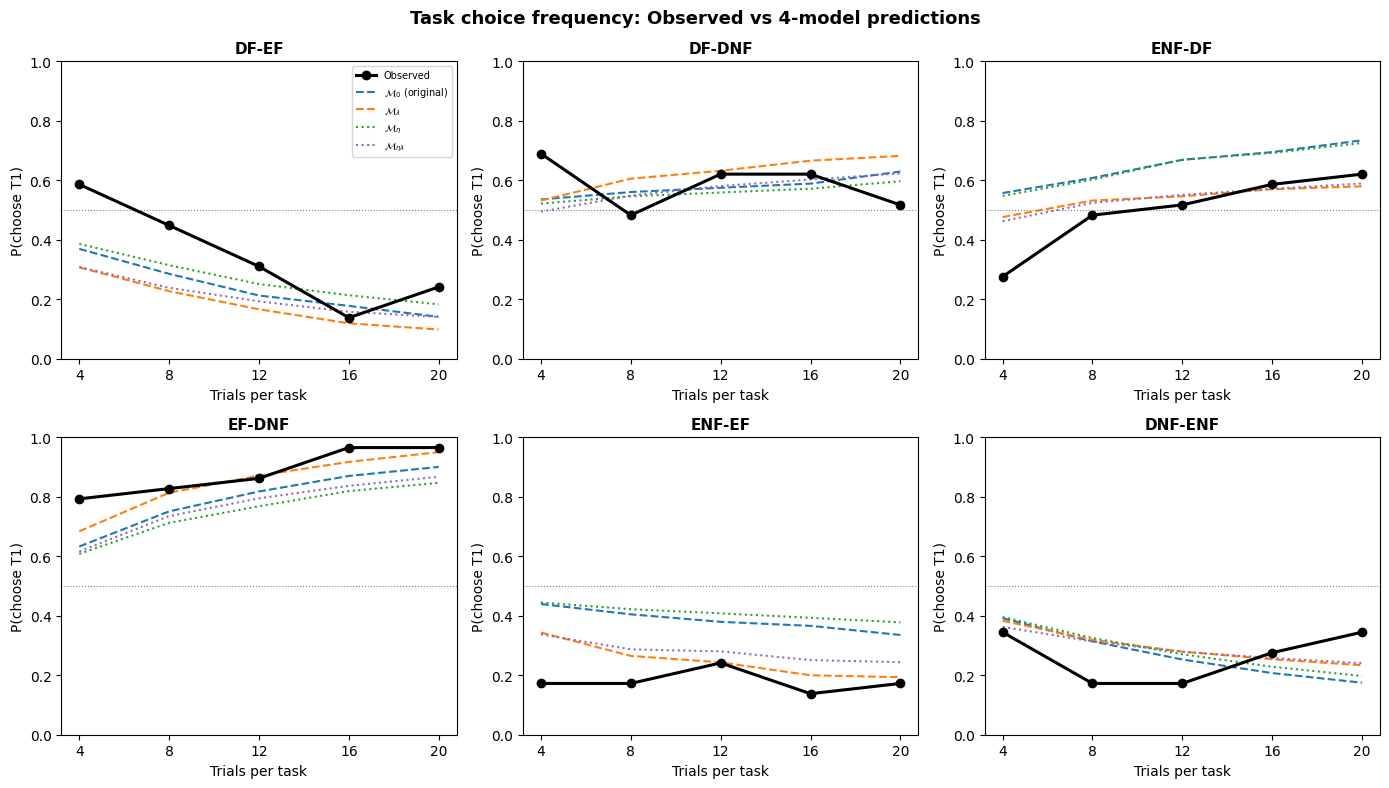

Observed T1 choice frequency by pairing × duration:
          4tr   8tr  12tr  16tr  20tr
DF-EF    0.59  0.45  0.31  0.14  0.24
DF-DNF   0.69  0.48  0.62  0.62  0.52
ENF-DF   0.28  0.48  0.52  0.59  0.62
EF-DNF   0.79  0.83  0.86  0.97  0.97
ENF-EF   0.17  0.17  0.24  0.14  0.17
DNF-ENF  0.34  0.17  0.17  0.28  0.34

  M0    MAE = 0.1266
  Mλ    MAE = 0.0871
  Mη    MAE = 0.1336
  Mηλ   MAE = 0.0971


In [107]:
# Group-level prediction (pWh by pairing and duration)

pairing_labels = ['DF-EF', 'DF-DNF', 'ENF-DF', 'EF-DNF', 'ENF-EF', 'DNF-ENF']
n_pairings = len(SERIES_DESIGN)
n_duration = len(DURATIONS_PER_TASK)

pWh_orig = np.zeros((n_pairings, n_duration, n_subjects))
pWh_lam  = np.zeros((n_pairings, n_duration, n_subjects))
pWh_eta  = np.zeros((n_pairings, n_duration, n_subjects))
pWh_comb = np.zeros((n_pairings, n_duration, n_subjects))
 
for subj_id, subject_data in all_subjects.items():
    p = fitted_all[subj_id]
    shared = {k: subject_data[k] for k in
              ['accuracylevel','fbtype','currenttask','target_left','seriestype','LBduration']}
    kch = subject_data['kch']
 
    # Original model
    res = bay_learning_model(
        **shared, kch=kch, kconf=p['kconf_orig'],
        nb_iter=50, random_state=42,
    )
    pWh_orig[:, :, subj_id] = res['pWh'][:, 0].reshape(n_pairings, n_duration)
 
    # Lambda model
    res = bay_learning_model_extended(
        **shared, kch=kch, kconf=p['kconf_lam'], lambda_risk=p['lambda'],
        nb_iter=50, random_state=42,
    )
    pWh_lam[:, :, subj_id] = res['pWh'][:, 0].reshape(n_pairings, n_duration)
 
    # Eta model
    res = bay_learning_model_eta(
        **shared, kch=kch, kconf=p['kconf_eta'], eta=p['eta'],
        nb_iter=50, random_state=42,
    )
    pWh_eta[:, :, subj_id] = res['pWh'][:, 0].reshape(n_pairings, n_duration)
 
    # Combined model
    res = bay_learning_model_combined(
        **shared, kch=kch, kconf=p['kconf_comb'],
        eta=p['eta_comb'], lambda_risk=p['lambda_comb'],
        nb_iter=50, random_state=42,
    )
    pWh_comb[:, :, subj_id] = res['pWh'][:, 0].reshape(n_pairings, n_duration)
 
# Observed
obs_mean = task1val_exp2.mean(axis=2)  # (6, 5)
 
# Plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
x = DURATIONS_PER_TASK
 
MODEL_SPECS = [
    ('pWh_orig', pWh_orig, 'tab:blue',   '--', '$\\mathcal{M}_0$ (original)'),
    ('pWh_lam',  pWh_lam,  'tab:orange',  '--', '$\\mathcal{M}_\\lambda$'),
    ('pWh_eta',  pWh_eta,  'tab:green',  ':',  '$\\mathcal{M}_\\eta$'),
    ('pWh_comb', pWh_comb, 'tab:purple', ':',  '$\\mathcal{M}_{\\eta\\lambda}$'),
]
 
for p_idx, (ax, label) in enumerate(zip(axes, pairing_labels)):
    ax.plot(x, obs_mean[p_idx, :], 'ko-', lw=2.2, markersize=6, label='Observed', zorder=5)
 
    for _, store, color, ls, mlabel in MODEL_SPECS:
        ax.plot(x, store[p_idx, :, :].mean(axis=1),
                color=color, ls=ls, lw=1.5, label=mlabel)
 
    ax.axhline(0.5, color='gray', lw=0.8, ls=':')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Trials per task')
    ax.set_ylabel('P(choose T1)')
    ax.set_xticks(x)
 
    if p_idx == 0:
        ax.legend(fontsize=7, loc='best')
 
plt.suptitle('Task choice frequency: Observed vs 4-model predictions',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/figures/04_4model_task_choice_frequency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Summary table
print("Observed T1 choice frequency by pairing × duration:")
print(pd.DataFrame(obs_mean, index=pairing_labels,
                   columns=[f'{d}tr' for d in DURATIONS_PER_TASK]).round(2))
print()
 
# Mean absolute error per model across all cells
for name, store in [('M0', pWh_orig), ('Mλ', pWh_lam), ('Mη', pWh_eta), ('Mηλ', pWh_comb)]:
    pred = store.mean(axis=2)  # (6, 5)
    mae = np.abs(pred - obs_mean).mean()
    print(f"  {name:<4}  MAE = {mae:.4f}")

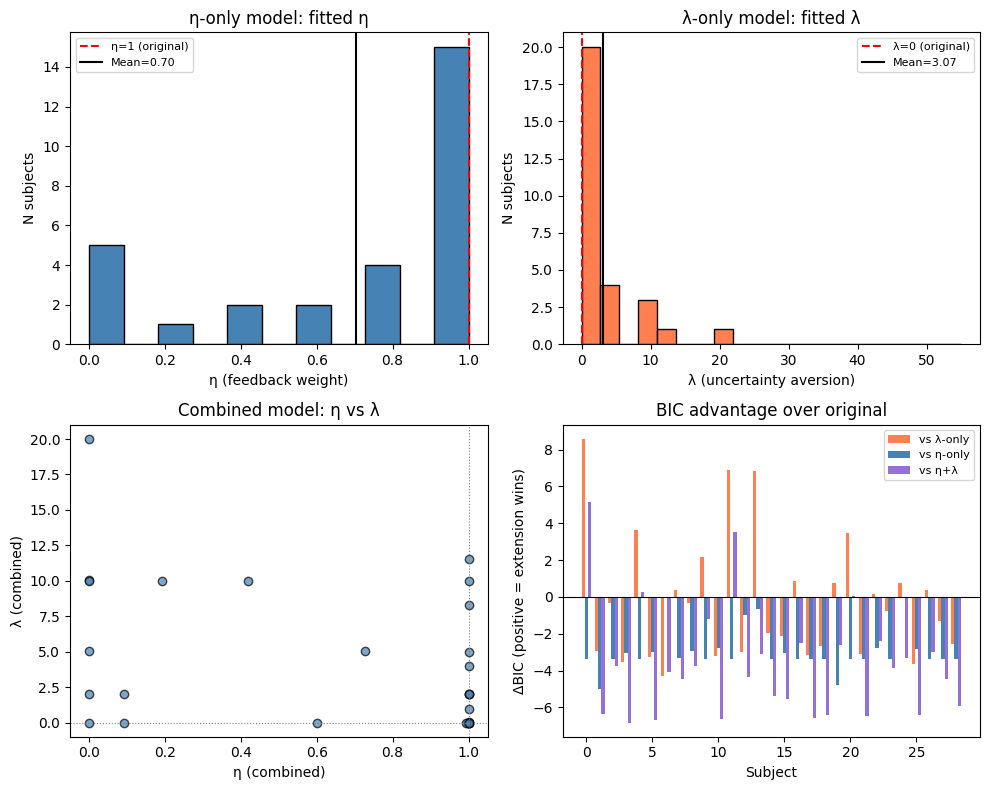

In [108]:
# Figures

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Eta distribution
ax = axes[0, 0]
ax.hist(df_bic['eta'], bins=np.linspace(0, 1, 12), edgecolor='black', color='steelblue')
ax.axvline(x=1.0, color='red', ls='--', label='η=1 (original)')
ax.axvline(x=df_bic['eta'].mean(), color='black', ls='-', label=f"Mean={df_bic['eta'].mean():.2f}")
ax.set_xlabel('η (feedback weight)')
ax.set_ylabel('N subjects')
ax.set_title('η-only model: fitted η')
ax.legend(fontsize=8)

# Lambda distribution
ax = axes[0, 1]
ax.hist(df_bic['lambda'], bins=20, range=(0, 55), edgecolor='black', color='coral')
ax.axvline(x=0.0, color='red', ls='--', label='λ=0 (original)')
ax.axvline(x=df_bic['lambda'].mean(), color='black', ls='-', label=f"Mean={df_bic['lambda'].mean():.2f}")
ax.set_xlabel('λ (uncertainty aversion)')
ax.set_ylabel('N subjects')
ax.set_title('λ-only model: fitted λ')
ax.legend(fontsize=8)

# Combined model parameter scatter
ax = axes[1, 0]
ax.scatter(df_bic['eta_comb'], df_bic['lambda_comb'], c='steelblue', edgecolors='black', alpha=0.7)
ax.set_xlabel('η (combined)')
ax.set_ylabel('λ (combined)')
ax.set_title('Combined model: η vs λ')
ax.axhline(y=0, color='grey', ls=':', lw=0.8)
ax.axvline(x=1, color='grey', ls=':', lw=0.8)

# BIC comparison for all 4 models
ax = axes[1, 1]
x = np.arange(len(df_bic))
w = 0.25
ax.bar(x - w, df_bic['bic_orig'] - df_bic['bic_lam'],  width=w, label='vs λ-only',  color='coral')
ax.bar(x,     df_bic['bic_orig'] - df_bic['bic_eta'],  width=w, label='vs η-only',  color='steelblue')
ax.bar(x + w, df_bic['bic_orig'] - df_bic['bic_comb'], width=w, label='vs η+λ',     color='mediumpurple')
ax.axhline(y=0, color='black', lw=0.8)
ax.set_xlabel('Subject')
ax.set_ylabel('ΔBIC (positive = extension wins)')
ax.set_title('BIC advantage over original')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../docs/figures/04_model_comparison_parameters.png', dpi=150, bbox_inches='tight')
plt.show()